## Initial Testing of LSTM Implementation

In [126]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import seaborn as sns

#Loading in data and dropping useless 
df = pd.read_csv('data/combined/all_years_combined_with_lebron.csv')
df = df.drop(columns=['Team', 'Pos', 'Awards', 'Player-additional','All_NBA_Label'])

#Adding time feature
df['Season_Normalized'] = (df['Season_End_Year'] - df['Season_End_Year'].mean()) / df['Season_End_Year'].std()

#Splitting by player 
players = df['Player'].unique()
train_players, test_players = train_test_split(players, test_size=0.2, random_state=42)

train_df = df[df['Player'].isin(train_players)].copy()
test_df  = df[df['Player'].isin(test_players)].copy()

#Feature columns
feature_cols = df.columns.drop(['Player', 'All_NBA_Target', 'Season_End_Year'])

#Scale features
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

df.head()

,Rk,Player,Age,G,GS,MP,FG,FGA,FG%,3P,...,DBPM,BPM,VORP,All_NBA_Target,Season_End_Year,LEBRON,O-LEBRON,D-LEBRON,WAR,Season_Normalized
0,104,Arron Afflalo,25,69,69,2324,312,627,0.498,105,...,-0.3,1.4,2.0,0,2011,0.44,1.01,-0.57,4.27,-1.679934
1,33,Ray Allen,35,80,80,2890,480,978,0.491,168,...,0.6,2.9,3.6,0,2011,1.02,0.61,0.41,6.45,-1.679934
2,165,Tony Allen,29,72,31,1494,251,492,0.510,4,...,3.5,3.6,2.1,0,2011,1.72,-0.37,2.09,4.03,-1.679934
3,214,Al-Farouq Aminu,20,81,14,1452,160,406,0.394,45,...,-0.1,-2.8,-0.3,0,2011,-2.11,-2.35,0.23,0.17,-1.679934
4,310,Lou Amundson,28,46,7,691,83,183,0.454,0,...,-1.4,-4.5,-0.4,0,2011,-1.99,-2.16,0.16,0.14,-1.679934


In [108]:
def build_sequences(df, seq_length=5):
    sequences, labels, indices = [], [], []
    
    df = df.sort_values(['Player', 'Season_End_Year'])
    
    for player, group in df.groupby('Player'):
        group = group.sort_values('Season_End_Year')
        
        data = group[feature_cols].values
        targets = group['All_NBA_Target'].values
        idxs = group.index.values
        
        if len(group) < seq_length:
            continue
        
        for i in range(len(group) - seq_length):
            sequences.append(data[i:i+seq_length])
            labels.append(targets[i+seq_length])
            indices.append(idxs[i+seq_length])
    
    return (np.array(sequences, dtype=np.float32), np.array(labels, dtype=np.float32), np.array(indices))

class AllNBALSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )
        
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

In [109]:
X_train, y_train, idx_train = build_sequences(train_df)
X_test, y_test, idx_test = build_sequences(test_df)
#Removing nan values that may poison model
X_train = np.nan_to_num(X_train, nan=0.0)
y_train = np.nan_to_num(y_train, nan=0.0)

In [110]:
model = AllNBALSTM(input_size=X_train.shape[2])

# Handle imbalance
pos_weight = torch.tensor([5.0])  # tune this
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Convert to tensors
X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.float32)

for epoch in range(50):
    model.train()
    
    logits = model(X_tensor).squeeze()
    loss = criterion(logits, y_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    
    # Prevent exploding gradients
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
    optimizer.step()
    
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 1.0390
Epoch 2, Loss: 1.0350
Epoch 3, Loss: 1.0316
Epoch 4, Loss: 1.0287
Epoch 5, Loss: 1.0253
Epoch 6, Loss: 1.0223
Epoch 7, Loss: 1.0187
Epoch 8, Loss: 1.0153
Epoch 9, Loss: 1.0118
Epoch 10, Loss: 1.0087
Epoch 11, Loss: 1.0060
Epoch 12, Loss: 1.0022
Epoch 13, Loss: 0.9987
Epoch 14, Loss: 0.9957
Epoch 15, Loss: 0.9921
Epoch 16, Loss: 0.9885
Epoch 17, Loss: 0.9853
Epoch 18, Loss: 0.9817
Epoch 19, Loss: 0.9779
Epoch 20, Loss: 0.9740
Epoch 21, Loss: 0.9710
Epoch 22, Loss: 0.9668
Epoch 23, Loss: 0.9636
Epoch 24, Loss: 0.9588
Epoch 25, Loss: 0.9567
Epoch 26, Loss: 0.9508
Epoch 27, Loss: 0.9478
Epoch 28, Loss: 0.9421
Epoch 29, Loss: 0.9375
Epoch 30, Loss: 0.9320
Epoch 31, Loss: 0.9275
Epoch 32, Loss: 0.9236
Epoch 33, Loss: 0.9192
Epoch 34, Loss: 0.9139
Epoch 35, Loss: 0.9085
Epoch 36, Loss: 0.9037
Epoch 37, Loss: 0.8983
Epoch 38, Loss: 0.8910
Epoch 39, Loss: 0.8867
Epoch 40, Loss: 0.8807
Epoch 41, Loss: 0.8764
Epoch 42, Loss: 0.8703
Epoch 43, Loss: 0.8622
Epoch 44, Loss: 0.85

In [111]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)
model.eval()
with torch.no_grad():
    test_probs = torch.sigmoid(model(X_test_tensor)).squeeze().numpy()
df_test_seq = test_df.loc[idx_test].copy()
df_test_seq['pred'] = test_probs

results = []

for year in sorted(df_test_seq['Season_End_Year'].unique()):
    season_df = df_test_seq[df_test_seq['Season_End_Year'] == year]
    
    if len(season_df) < 15:
        continue
    
    top15 = season_df.sort_values('pred', ascending=False).head(15)
    actual = season_df[season_df['All_NBA_Target'] == 1]
    
    overlap = len(set(top15.index) & set(actual.index))
    results.append(overlap)
    
    print(f"{year}: {overlap}")

print("\nTest Average overlap:", np.mean(results))

2016: 0
2017: 0
2018: 0
2019: 0
2020: 0
2021: 2
2022: 1
2023: 1
2024: 1
2025: 1

Test Average overlap: 0.6


## Testing with Advanced Dataset


In [73]:
# Load datasets and drop unneeded values
advanced_df = pd.read_csv('data/model_datasets/advanced_dataset.csv')
advanced_df = advanced_df.drop(columns=['Team', 'Pos'])
combined_df = pd.read_csv('data/combined/all_years_combined_with_lebron.csv')

advanced_df['Player'] = combined_df['Player']
print(combined_df[['Player', 'Season_End_Year']].head(10))
print(advanced_df.head(10))

            Player  Season_End_Year
0    Arron Afflalo             2011
1        Ray Allen             2011
2       Tony Allen             2011
3  Al-Farouq Aminu             2011
4     Lou Amundson             2011
5   Chris Andersen             2011
6   James Anderson             2011
7    Ryan Anderson             2011
8  Carmelo Anthony             2011
9     Joel Anthony             2011
    Age   PER    TS%   3PAr    FTr  ORB%  DRB%  TRB%  AST%  STL%  ...  DWS  \
0  25.0  13.6  0.620  0.396  0.260   2.3   9.9   6.2  10.9   0.7  ...  1.4   
1  35.0  16.4  0.615  0.387  0.224   2.3   9.0   5.8  12.7   1.4  ...  4.2   
2  29.0  18.4  0.562  0.047  0.370   5.5   9.9   7.7  10.9   4.5  ...  2.7   
3  20.0   9.6  0.499  0.352  0.293   6.1  15.4  10.8   6.4   2.1  ...  1.4   
4  28.0  11.5  0.452  0.000  0.475  13.0  17.4  15.2   3.5   1.0  ...  0.5   
5  32.0  19.0  0.636  0.007  0.985  12.2  22.1  17.3   4.0   1.6  ...  1.2   
6  21.0   8.5  0.529  0.568  0.222   0.8   8.3   4.7   9.2

In [77]:
advanced_df['Season_Normalized'] = (advanced_df['Season_End_Year'] - advanced_df['Season_End_Year'].mean()) / advanced_df['Season_End_Year'].std()

players = advanced_df['Player'].unique()
train_players, test_players = train_test_split(players, test_size=0.2, random_state=42)

train_df = advanced_df[advanced_df['Player'].isin(train_players)].copy()
test_df  = advanced_df[advanced_df['Player'].isin(test_players)].copy()

feature_cols = advanced_df.columns.drop(['All_NBA_Target', 'Season_End_Year', 'Player'])

scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols]  = scaler.transform(test_df[feature_cols])

df_adv.head()

,Age,PER,TS%,3PAr,FTr,ORB%,DRB%,TRB%,AST%,STL%,...,DWS,WS,WS/48,OBPM,DBPM,BPM,VORP,Season_End_Year,All_NBA_Target,Season_Normalized
0,25.0,13.6,0.620,0.396,0.260,2.3,9.9,6.2,10.9,0.7,...,1.4,6.2,0.128,1.7,-0.3,1.4,2.0,2011,0,-1.679934
1,35.0,16.4,0.615,0.387,0.224,2.3,9.0,5.8,12.7,1.4,...,4.2,10.0,0.166,2.3,0.6,2.9,3.6,2011,0,-1.679934
2,29.0,18.4,0.562,0.047,0.370,5.5,9.9,7.7,10.9,4.5,...,2.7,4.7,0.152,0.1,3.5,3.6,2.1,2011,0,-1.679934
3,20.0,9.6,0.499,0.352,0.293,6.1,15.4,10.8,6.4,2.1,...,1.4,0.7,0.022,-2.7,-0.1,-2.8,-0.3,2011,0,-1.679934
4,28.0,11.5,0.452,0.000,0.475,13.0,17.4,15.2,3.5,1.0,...,0.5,0.6,0.044,-3.1,-1.4,-4.5,-0.4,2011,0,-1.679934


In [78]:
X_train, y_train, idx_train = build_sequences(train_df)
X_test, y_test, idx_test = build_sequences(test_df)
X_train = np.nan_to_num(X_train, nan=0.0)
y_train = np.nan_to_num(y_train, nan=0.0)

In [79]:
model = AllNBALSTM(input_size=X_train.shape[2])

pos_weight = torch.tensor([5.0])  # tune this
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

X_tensor = torch.tensor(X_train, dtype=torch.float32)
y_tensor = torch.tensor(y_train, dtype=torch.float32)

for epoch in range(100):
    model.train()
    
    logits = model(X_tensor).squeeze()
    loss = criterion(logits, y_tensor)
    
    optimizer.zero_grad()
    loss.backward()
    
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    
    optimizer.step()
    
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 1.0098
Epoch 2, Loss: 1.0093
Epoch 3, Loss: 1.0089
Epoch 4, Loss: 1.0084
Epoch 5, Loss: 1.0080
Epoch 6, Loss: 1.0076
Epoch 7, Loss: 1.0072
Epoch 8, Loss: 1.0069
Epoch 9, Loss: 1.0066
Epoch 10, Loss: 1.0063
Epoch 11, Loss: 1.0060
Epoch 12, Loss: 1.0058
Epoch 13, Loss: 1.0056
Epoch 14, Loss: 1.0055
Epoch 15, Loss: 1.0053
Epoch 16, Loss: 1.0052
Epoch 17, Loss: 1.0051
Epoch 18, Loss: 1.0050
Epoch 19, Loss: 1.0049
Epoch 20, Loss: 1.0048
Epoch 21, Loss: 1.0048
Epoch 22, Loss: 1.0047
Epoch 23, Loss: 1.0047
Epoch 24, Loss: 1.0046
Epoch 25, Loss: 1.0045
Epoch 26, Loss: 1.0045
Epoch 27, Loss: 1.0044
Epoch 28, Loss: 1.0043
Epoch 29, Loss: 1.0043
Epoch 30, Loss: 1.0042
Epoch 31, Loss: 1.0041
Epoch 32, Loss: 1.0039
Epoch 33, Loss: 1.0038
Epoch 34, Loss: 1.0037
Epoch 35, Loss: 1.0035
Epoch 36, Loss: 1.0033
Epoch 37, Loss: 1.0030
Epoch 38, Loss: 1.0028
Epoch 39, Loss: 1.0026
Epoch 40, Loss: 1.0025
Epoch 41, Loss: 1.0024
Epoch 42, Loss: 1.0023
Epoch 43, Loss: 1.0022
Epoch 44, Loss: 1.00

In [80]:
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_tensor)).squeeze().numpy()

df_seq = train_df.loc[idx_train].copy()
df_seq['pred'] = probs

for year in df_seq['Season_End_Year'].unique():
    season_df = df_seq[df_seq['Season_End_Year'] == year]
    
    top15 = season_df.sort_values('pred', ascending=False).head(15)
    actual = season_df[season_df['All_NBA_Target'] == 1]
    
    overlap = len(set(top15.index) & set(actual.index))
    print(year, overlap)

2020 2
2021 2
2022 1
2023 1
2024 2
2025 0
2017 1
2018 2
2019 2
2016 1


## Testing Different Modifications

In [117]:
results = []
#Testing out varying lengths of time and different sizes for hidden
hidden_sizes = [32, 64, 128]
epoch_options = [20, 50, 100]

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

for h in hidden_sizes:
    for num_epochs in epoch_options:
        print(f"\nTraining model: hidden={h}, epochs={num_epochs}")
        
        model = AllNBALSTM(input_size=X_train.shape[2], hidden_size=h)
        optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
        criterion = nn.BCEWithLogitsLoss()
        
        #Training
        for epoch in range(num_epochs):
            model.train()
            
            logits = model(X_train_tensor).squeeze()
            loss = criterion(logits, y_train_tensor)
            
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        final_loss = loss.item()
        
        #Evaluation of test data
        model.eval()
        with torch.no_grad():
            test_probs = torch.sigmoid(model(X_test_tensor)).squeeze().numpy()
        
        df_test_seq = test_df.loc[idx_test].copy()
        df_test_seq['pred'] = test_probs
        
        yearly_results = []
        
        for year in sorted(df_test_seq['Season_End_Year'].unique()):
            season_df = df_test_seq[df_test_seq['Season_End_Year'] == year]
            
            if len(season_df) < 15:
                continue
            
            top15 = season_df.sort_values('pred', ascending=False).head(15)
            actual = season_df[season_df['All_NBA_Target'] == 1]
            
            overlap = len(set(top15.index) & set(actual.index))
            yearly_results.append(overlap)
        
        avg_overlap = np.mean(yearly_results) if yearly_results else 0
        
        #Results get stored
        results.append({'hidden_size': h, 'epochs': num_epochs, 'final_loss': final_loss, 'test_overlap': avg_overlap})
        
        print(f"Final Loss: {final_loss:.4f}, Test Overlap: {avg_overlap:.2f}")


Training model: hidden=32, epochs=20
Final Loss: 0.6252, Test Overlap: 0.30

Training model: hidden=32, epochs=50
Final Loss: 0.6568, Test Overlap: 0.40

Training model: hidden=32, epochs=100
Final Loss: 0.5958, Test Overlap: 0.30

Training model: hidden=64, epochs=20
Final Loss: 0.6668, Test Overlap: 0.60

Training model: hidden=64, epochs=50
Final Loss: 0.5774, Test Overlap: 0.60

Training model: hidden=64, epochs=100
Final Loss: 0.5301, Test Overlap: 0.60

Training model: hidden=128, epochs=20
Final Loss: 0.6323, Test Overlap: 0.60

Training model: hidden=128, epochs=50
Final Loss: 0.5536, Test Overlap: 0.60

Training model: hidden=128, epochs=100
Final Loss: 0.2029, Test Overlap: 0.50


   hidden_size  epochs  final_loss  test_overlap
0           32      20    0.625196           0.3
1           32      50    0.656805           0.4
2           32     100    0.595781           0.3
3           64      20    0.666756           0.6
4           64      50    0.577431           0.6
5           64     100    0.530063           0.6
6          128      20    0.632340           0.6
7          128      50    0.553582           0.6
8          128     100    0.202852           0.5


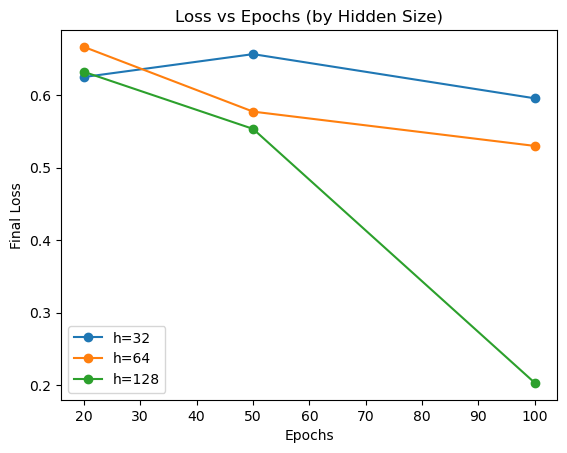

In [122]:
results_df = pd.DataFrame(results)
print(results_df)
for h in hidden_sizes:
    subset = results_df[results_df['hidden_size'] == h]
    plt.plot(subset['epochs'], subset['final_loss'], marker='o', label=f'h={h}')

plt.xlabel("Epochs")
plt.ylabel("Final Loss")
plt.title("Loss vs Epochs (by Hidden Size)")
plt.legend()
plt.show()

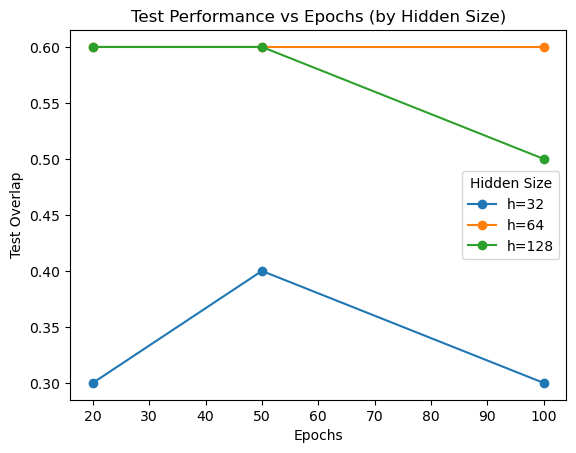

In [123]:
plt.figure()
for h in hidden_sizes:
    subset = results_df[results_df['hidden_size'] == h]
    subset = subset.sort_values('epochs')  
    plt.plot(subset['epochs'], subset['test_overlap'], marker='o', label=f'h={h}')
    
plt.xlabel("Epochs")
plt.ylabel("Test Overlap")
plt.title("Test Performance vs Epochs (by Hidden Size)")
plt.legend(title="Hidden Size")
plt.show()

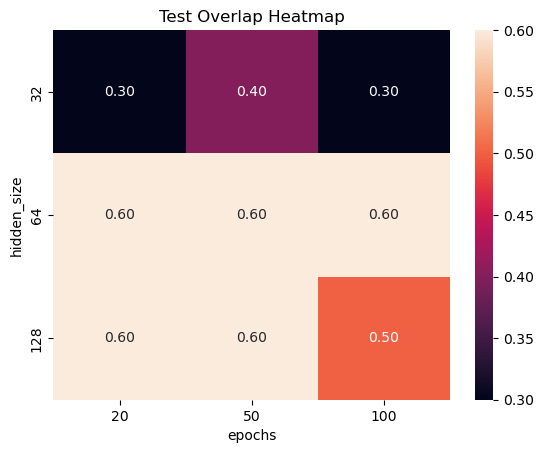

In [127]:
pivot = results_df.pivot(
    index='hidden_size',
    columns='epochs',
    values='test_overlap'
)

sns.heatmap(pivot, annot=True, fmt=".2f")
plt.title("Test Overlap Heatmap")
plt.show()